# Notebook 03 — Política Baseline

Objetivo: estabelecer um baseline de decisão que servirá de referência para comparar o Thompson Sampling.

Políticas avaliadas:
- **Random**: seleciona braços uniformemente ao acaso.
- **Greedy**: sempre seleciona o braço com maior taxa de conversão observada até o momento.

Método de avaliação: **Replayer offline** — conta apenas os eventos em que a política escolheria o mesmo braço que foi servido historicamente, garantindo estimativa imparcial.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datathon_offerexp.policies import RandomPolicy, GreedyPolicy
from datathon_offerexp.evaluation import replay_evaluate, compute_regret, summarize

sns.set_theme(style='whitegrid')
SEED = 42

In [2]:
events = pd.read_csv('../data/synthetic_enrichment/offer_events.csv')
catalog = pd.read_csv('../data/synthetic_enrichment/offer_catalog.csv')

print('Eventos:', events.shape)
print('\nReward médio por braço:')
print(events.groupby('arm_name')['reward'].mean().round(4))

Eventos: (41188, 29)

Reward médio por braço:
arm_name
cartao_premium         0.1186
educacao_financeira    0.1112
sem_oferta             0.1110
simulador_credito      0.1098
Name: reward, dtype: float64


## Taxa de conversão real por braço (oráculo)

Calculamos a taxa real de cada braço — este é o valor máximo que qualquer política online poderia atingir **se soubesse de antemão qual braço é o melhor**. Usamos para calcular o regret.

In [3]:
oracle_rates = events.groupby('arm_id')['reward'].mean()
best_arm_id = int(oracle_rates.idxmax())
best_arm_rate = float(oracle_rates.max())

print(f'Melhor braço (oráculo): arm_id={best_arm_id} — taxa {best_arm_rate:.4f}')
print(oracle_rates.round(4))

Melhor braço (oráculo): arm_id=3 — taxa 0.1186
arm_id
0    0.1110
1    0.1112
2    0.1098
3    0.1186
Name: reward, dtype: float64


## Política Random

In [4]:
random_policy = RandomPolicy()
df_random = replay_evaluate(random_policy, events, seed=SEED)
df_random = compute_regret(df_random, best_arm_rate)

print(summarize(df_random, 'Random'))
df_random.tail()

{'policy': 'Random', 'rounds': 10307, 'avg_reward': 0.109, 'total_reward': 1123.0}


,round,arm_id,arm_name,reward,cumulative_reward,avg_reward,expected_best,cumulative_regret
10302,10303,0,sem_oferta,0.0,1120.0,0.108706,1222.406869,102.406869
10303,10304,1,educacao_financeira,1.0,1121.0,0.108793,1222.525515,101.525515
10304,10305,1,educacao_financeira,1.0,1122.0,0.108879,1222.644160,100.644160
10305,10306,0,sem_oferta,0.0,1122.0,0.108869,1222.762806,100.762806
10306,10307,1,educacao_financeira,1.0,1123.0,0.108955,1222.881452,99.881452


## Política Greedy

In [5]:
greedy_policy = GreedyPolicy()
df_greedy = replay_evaluate(greedy_policy, events, seed=SEED)
df_greedy = compute_regret(df_greedy, best_arm_rate)

print(summarize(df_greedy, 'Greedy'))
df_greedy.tail()

{'policy': 'Greedy', 'rounds': 10178, 'avg_reward': 0.1109, 'total_reward': 1129.0}


,round,arm_id,arm_name,reward,cumulative_reward,avg_reward,expected_best,cumulative_regret
10173,10174,1,educacao_financeira,1.0,1126.0,0.110674,1207.101571,81.101571
10174,10175,1,educacao_financeira,1.0,1127.0,0.110762,1207.220217,80.220217
10175,10176,1,educacao_financeira,0.0,1127.0,0.110751,1207.338862,80.338862
10176,10177,1,educacao_financeira,1.0,1128.0,0.110838,1207.457508,79.457508
10177,10178,1,educacao_financeira,1.0,1129.0,0.110926,1207.576154,78.576154


## Comparação visual — Reward acumulado e Regret

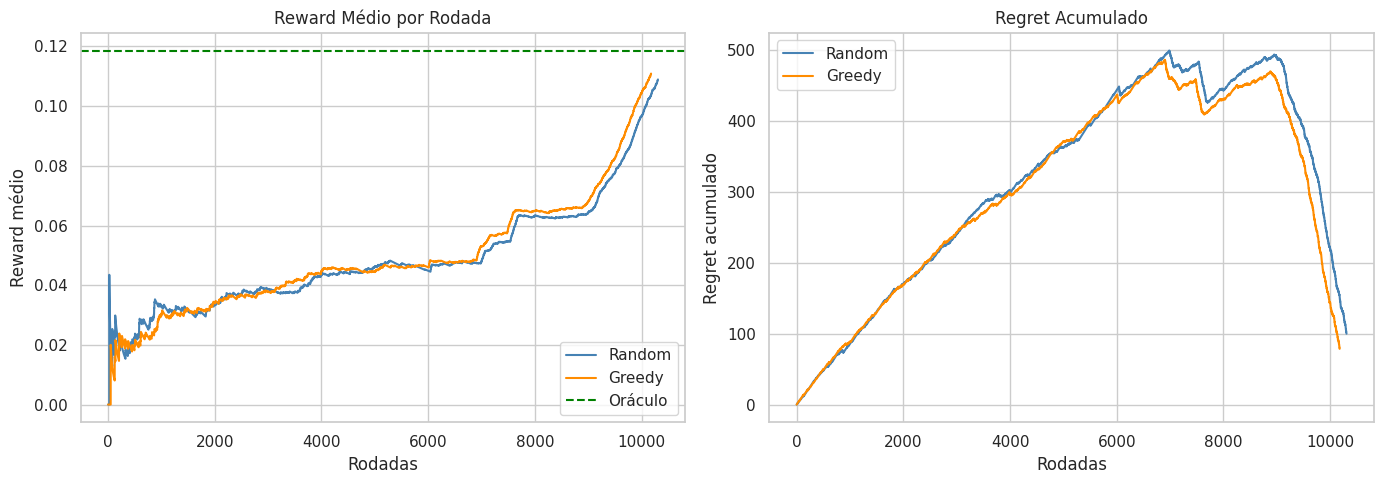

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_random['round'], df_random['avg_reward'], label='Random', color='steelblue')
axes[0].plot(df_greedy['round'], df_greedy['avg_reward'], label='Greedy', color='darkorange')
axes[0].axhline(best_arm_rate, linestyle='--', color='green', label='Oráculo')
axes[0].set_title('Reward Médio por Rodada')
axes[0].set_xlabel('Rodadas')
axes[0].set_ylabel('Reward médio')
axes[0].legend()

axes[1].plot(df_random['round'], df_random['cumulative_regret'], label='Random', color='steelblue')
axes[1].plot(df_greedy['round'], df_greedy['cumulative_regret'], label='Greedy', color='darkorange')
axes[1].set_title('Regret Acumulado')
axes[1].set_xlabel('Rodadas')
axes[1].set_ylabel('Regret acumulado')
axes[1].legend()

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/baseline_comparison.png', dpi=150)
plt.show()

## Distribuição de braços selecionados

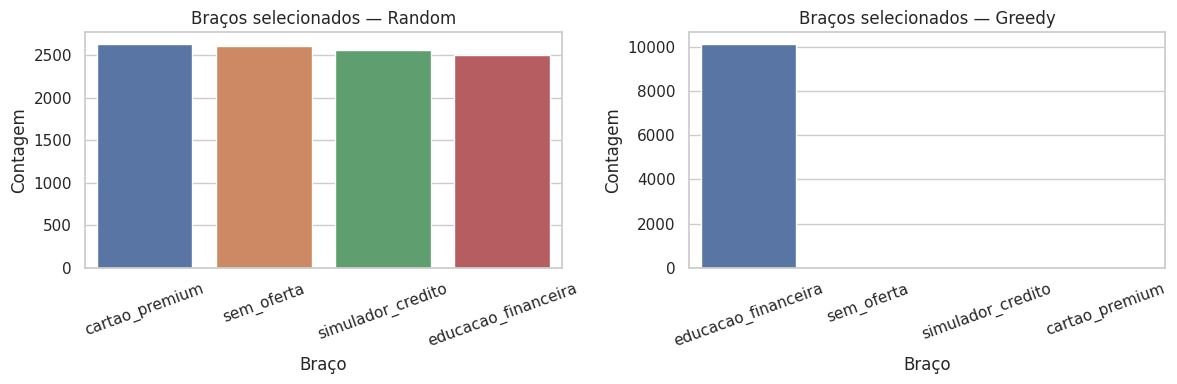

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes, [df_random, df_greedy], ['Random', 'Greedy']):
    counts = df['arm_name'].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title(f'Braços selecionados — {title}')
    ax.set_xlabel('Braço')
    ax.set_ylabel('Contagem')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Resumo do Baseline

**Conclusão**: A política Random distribui as seleções igualmente e serve como piso de referência. A Greedy converge para o melhor braço observado, mas exibe exploitation prematuro — sem explorar braços potencialmente melhores após poucas observações. O Thompson Sampling (Notebook 04) equilibra exploração e explotação de forma probabilística, reduzindo o regret total.

In [8]:
summary = pd.DataFrame([
    summarize(df_random, 'Random'),
    summarize(df_greedy, 'Greedy'),
    {'policy': 'Oráculo', 'rounds': '—', 'avg_reward': round(best_arm_rate, 4), 'total_reward': '—'},
])
print(summary.to_string(index=False))

 policy rounds  avg_reward total_reward
 Random  10307      0.1090       1123.0
 Greedy  10178      0.1109       1129.0
Oráculo      —      0.1186            —
